In [37]:
#====================================================================
#==     MACHINE LEARNING COURSEWORK - 2    STUDENT ID - A00096829  ==
#====================================================================

In [38]:
# SIMPLE WORKFLOW
#==================
# pip install libraries
#        ↓
# import libraries in Python
#        ↓
# load dataset
#        ↓
# build CNN model
#        ↓
# train and evaluate
#        ↓
# get final results
#        ↓
# compare with other models

In [39]:
# TensorFlow Commands
#=====================

# pip install tensorflow
# pip install tensorflow-datasets
# pip install matplotlib
# pip install scikit-learn

In [40]:
# IMPORT THE REQURIED LIBRARIES
#===============================

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt  
import numpy as np
import random
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

In [41]:
# Print TensorFlow version to verify.
#=====================================
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [42]:
# Define input and output variables
# ======================================
for image, label in train_ds.take(1):
    X = image
    y = label

print("Input shape:", X.shape)
print("Output label:", y.numpy())

Input shape: (32, 64, 64, 3)
Output label: [1 0 8 3 9 8 0 2 4 6 9 6 6 1 0 6 6 7 7 5 8 0 1 2 3 4 4 0 6 2 7 6]


In [43]:
# Load STL-10 dataset
# split both training and testing sets
(train_ds, test_ds), ds_info = tfds.load(
    'stl10',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

# Print dataset to verify correct loading
print("Dataset loaded successfully")
print("Number of training samples:", ds_info.splits['train'].num_examples)
print("Number of testing samples:", ds_info.splits['test'].num_examples)

# Print class all names
print("Class names:", ds_info.features['label'].names)

Dataset loaded successfully
Number of training samples: 5000
Number of testing samples: 8000
Class names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [44]:
# Image Preprocessing
# ===================
# Image resize (reduce from 96x96 to 64x64)
IMG_SIZE = 64

# Define preprocessing function
def preprocess(image, label):
    
    # Resize image to 64x64
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    
    # Normalize pixel values from [0,255] to [0,1]
    image = image / 255.0
    
    return image, label

# Apply preprocessing to training and test datasets
train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

print("Preprocessing applied successfully!")

Preprocessing applied successfully!


In [45]:
# Check one processed sample
# ==========================
for image, label in train_ds.take(1):
    
    print("New image shape:", image.shape)  
    
    print("Minimum pixel value:", tf.reduce_min(image).numpy())  
    print("Maximum pixel value:", tf.reduce_max(image).numpy())  

New image shape: (64, 64, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [46]:
# Get the dataset information
# ============================
# Get total number of training samples
TOTAL_TRAIN = ds_info.splits['train'].num_examples

# Calculate 80% of data for training
TRAIN_SIZE = int(0.8 * TOTAL_TRAIN)

# Reload full training set (important for proper splitting)
full_train = tfds.load('stl10', split='train', as_supervised=True)
full_train = full_train.map(preprocess)

# Take first 80% as training set
train_ds = full_train.take(TRAIN_SIZE)

# Skip first 80% and use remaining 20% as validation set
val_ds = full_train.skip(TRAIN_SIZE)

print("Training samples:", TRAIN_SIZE)
print("Validation samples:", TOTAL_TRAIN - TRAIN_SIZE)

Training samples: 4000
Validation samples: 1000


In [47]:
# Define batch size
#==================
BATCH_SIZE = 32

# Batch datasets
train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

print("Batching complete!")

# Check one batch
for images, labels in train_ds.take(1):
    
    print("Batch image shape:", images.shape)  # Expected: (32, 64, 64, 3)
    print("Batch label shape:", labels.shape)  # Expected: (32,)

Batching complete!
Batch image shape: (32, 64, 64, 3)
Batch label shape: (32,)


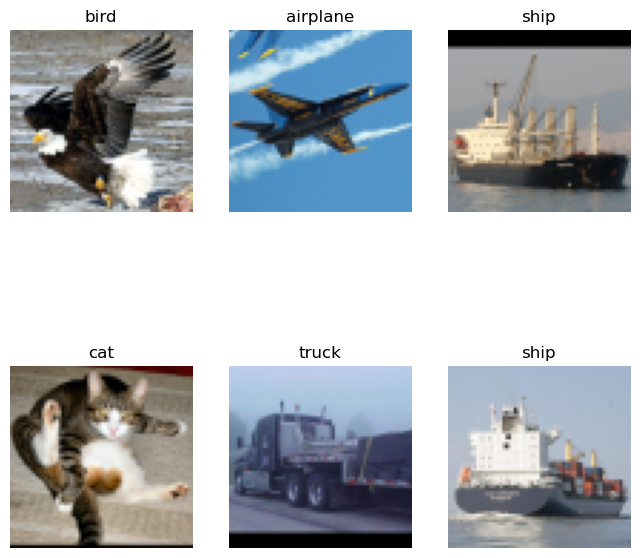

In [48]:
# Get class names
#================
class_names = ds_info.features['label'].names

# Display 6 sample images
for images, labels in train_ds.take(1):
    
    plt.figure(figsize=(8,8))
    
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
    
    plt.show()

In [49]:
#Experiment with Different Layer Types
#=====================================
from tensorflow.keras import layers, models
model = models.Sequential([
    
    layers.Input(shape=(224,224,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),   # helps reduce overfitting

    layers.Dense(37, activation='softmax')
])

#Experiment with Activation Functions
#------------------------------------
layers.Dense(128, activation='relu')
layers.Dense(37, activation='softmax')

#compile optimiser
#-----------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Experiment with Architecture (CNN)
#-----------------------------------
layers.Conv2D(32, (3,3), activation='relu')
layers.MaxPooling2D(2,2)

layers.Conv2D(64, (3,3), activation='relu')
layers.MaxPooling2D(2,2)

layers.Conv2D(128, (3,3), activation='relu')
layers.MaxPooling2D(2,2)

<MaxPooling2D name=max_pooling2d_14, built=True>

In [50]:
# Build the CNN Model
#====================

# Create Sequential model
model = models.Sequential()

# Input Layer
# ------------
# Input shape (64, 64, 3)
model.add(layers.Input(shape=(64, 64, 3)))

# Hidden Layer Block 1
# ---------------------
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Hidden Layer Block 2
# ---------------------
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Hidden Layer Block 3
# --------------------
model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Flatten before Dense layers
# -------------------------
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(128, activation='relu'))

# Dropout to reduce overfitting
model.add(layers.Dropout(0.5))

# Output Layer
# -------------
model.add(layers.Dense(10, activation='softmax'))

In [51]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [52]:
# compilation test of CNN model
#------------------------------
model.compile(
    optimizer='adam',                       
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [53]:
# Train the model
#----------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 128ms/step - accuracy: 0.2170 - loss: 2.3568 - val_accuracy: 0.1020 - val_loss: 6.8528
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - accuracy: 0.2890 - loss: 1.9101 - val_accuracy: 0.1760 - val_loss: 2.6550
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.3180 - loss: 1.7725 - val_accuracy: 0.1750 - val_loss: 3.0367
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - accuracy: 0.3587 - loss: 1.6913 - val_accuracy: 0.3690 - val_loss: 1.6749
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.3758 - loss: 1.5845 - val_accuracy: 0.3640 - val_loss: 1.9157
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 142ms/step - accuracy: 0.3887 - loss: 1.5510 - val_accuracy: 0.4510 - val_loss: 1.5846
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.4308 - loss: 1.4668 - val_accuracy: 0.4460 - val_loss: 1.5388
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - accuracy: 0.4647 - loss: 1

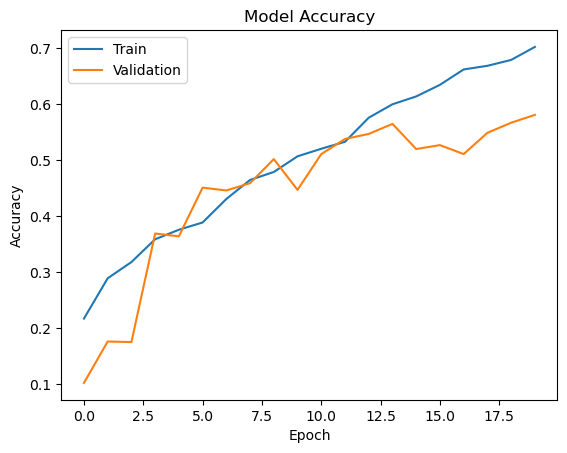

In [54]:
# Plot Accuracy
#--------------

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

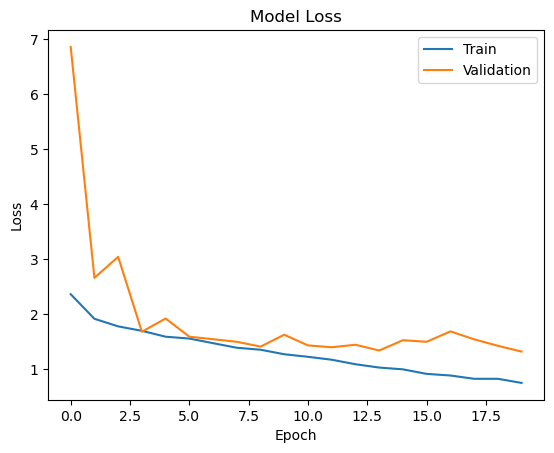

In [55]:
# Plot Loss
#-----------
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [56]:
#Evaluate the Test results of given Dataset
#------------------------------------------
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5855 - loss: 1.3263
Test Accuracy: 0.5855000019073486
Test Loss: 1.3263095617294312


In [57]:
# Confusion Matrix
#------------------
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━

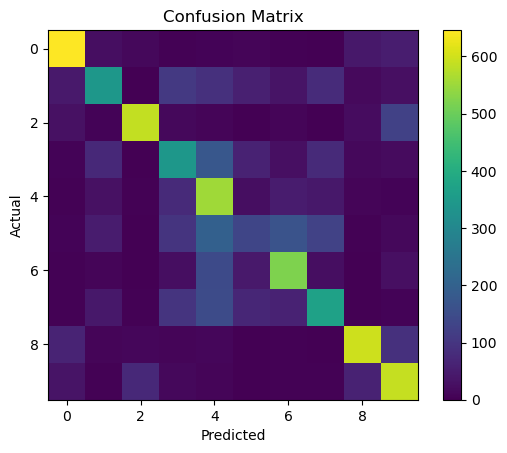

In [58]:
# Plot Confusion Matrix
#----------------------
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [59]:
# Classification Report (Precision, Recall, F1)
#----------------------------------------------

print(classification_report(y_true, y_pred))

# Precision          - Correct positive predictions
# Recall             - Ability to detect all class instances
# F1-score           - Balance between precision & recall
# Confusion Matrix	 - Class-level performance

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       800
           1       0.58      0.43      0.49       800
           2       0.84      0.73      0.78       800
           3       0.43      0.43      0.43       800
           4       0.41      0.69      0.52       800
           5       0.34      0.17      0.23       800
           6       0.59      0.65      0.62       800
           7       0.51      0.46      0.48       800
           8       0.77      0.75      0.76       800
           9       0.62      0.74      0.67       800

    accuracy                           0.59      8000
   macro avg       0.59      0.59      0.58      8000
weighted avg       0.59      0.59      0.58      8000



In [60]:
# DECISION TREE MODEL (LO3 Requirement)
# Using same train_ds and test_ds
# ======================================

# Convert TensorFlow dataset to NumPy arrays
X_train_dt = []
y_train_dt = []

for images, labels in train_ds.unbatch():
    X_train_dt.append(tf.reshape(images, [-1]).numpy())
    y_train_dt.append(labels.numpy())

X_test_dt = []
y_test_dt = []

for images, labels in test_ds.unbatch():
    X_test_dt.append(tf.reshape(images, [-1]).numpy())
    y_test_dt.append(labels.numpy())

X_train_dt = np.array(X_train_dt)
y_train_dt = np.array(y_train_dt)
X_test_dt = np.array(X_test_dt)
y_test_dt = np.array(y_test_dt)

print("Decision Tree data prepared!")

Decision Tree data prepared!


In [61]:
# Train Decision Tree
#---------------------
dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)

dt_model.fit(X_train_dt, y_train_dt)

# Predict
dt_predictions = dt_model.predict(X_test_dt)

# Accuracy
dt_accuracy = accuracy_score(y_test_dt, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.258875


In [62]:
# FINAL MODEL COMPARISON
# =======================

print("\n================ FINAL MODEL COMPARISON ================\n")

print("┌──────┬───────────────────────────────┬───────────────┐")
print("│ S.No │ Model                         │ Accuracy (%)  │")
print("├──────┼───────────────────────────────┼───────────────┤")
print(f"│ {1:<4} │ {'CNN':<29} │ {test_accuracy*100:>13.5f} │")
print(f"│ {2:<4} │ {'Decision Tree':<29} │ {dt_accuracy*100:>13.5f} │")
print("└──────┴───────────────────────────────┴───────────────┘")


================ FINAL MODEL COMPARISON ================

┌──────┬───────────────────────────────┬───────────────┐
│ S.No │ Model                         │ Accuracy (%)  │
├──────┼───────────────────────────────┼───────────────┤
│ 1    │ CNN                           │      58.55000 │
│ 2    │ Decision Tree                 │      25.88750 │
└──────┴───────────────────────────────┴───────────────┘
